# Notebook 03 — Arithmetic Asian Option: Monte Carlo Pricing

**Option Pricing Horizon** | Task 3 of 5

---

## Learning Objectives
1. Understand why no closed-form exists for arithmetic Asian options
2. Implement and understand the log-Euler GBM path simulation
3. Compare crude MC, antithetic variates, and geometric control variate
4. Analyse convergence: SE ∝ M^{-1/2} and log-log slope verification
5. Quantify variance-reduction ratios numerically

---

## 1. Why No Closed-Form for Arithmetic Average?

The arithmetic average $A_{\text{arith}} = \frac{1}{N}\sum_{i=1}^{N} S_{t_i}$
is a **sum of log-normal random variables**.

While each $S_{t_i}$ is log-normal under GBM, their sum is **not** log-normal
(or any other standard distribution), so no closed-form pricing integral exists.

We must use numerical methods. We choose **Monte Carlo simulation** because:
- It is straightforward to implement
- It applies to any payoff structure
- Variance reduction techniques make it highly accurate
- The simulation is bias-free when using the exact log-Euler scheme

---

## 2. Algorithm: Log-Euler GBM Simulation

**Key property**: For GBM, the exact discrete solution is:

$$S_{t+\Delta t} = S_t \cdot \exp\!\left[(r - \tfrac{\sigma^2}{2})\Delta t + \sigma\sqrt{\Delta t}\, Z\right], \quad Z\sim\mathcal{N}(0,1)$$

This is **not an approximation** — it is the exact solution of the SDE.
There is **zero discretisation bias**.

**Algorithm Steps:**
1. Draw $M \times N$ standard normal innovations $Z$
2. Compute cumulative log-returns: $\ln(S_{t_j}/S_0) = \sum_{i=1}^{j}[(r-\sigma^2/2)\Delta t + \sigma\sqrt{\Delta t}\,Z_i]$
3. Exponentiate: $S_{t_j} = S_0 \exp(\cdots)$
4. Compute payoffs: $V_m = e^{-rT}\max(A_{\text{arith},m} - K,\, 0)$
5. Estimate: $\hat{C} = \frac{1}{M}\sum_m V_m$, with SE $= \hat{\sigma}_V/\sqrt{M}$

**Complexity**: $O(M \times N)$ — linear in both paths and steps.
Numba JIT parallelism reduces wall-clock time by a factor equal to the number of CPU cores.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import time
import warnings
warnings.filterwarnings('ignore')

from option_pricing_horizon.common.market_params import MarketParams
from option_pricing_horizon.common.simulation import simulate_gbm_paths
from option_pricing_horizon.asian.monte_carlo import arithmetic_asian_mc, ArithmeticMCResult
from option_pricing_horizon.asian.geometric import geometric_asian_call
from option_pricing_horizon.asian.convergence import (
    convergence_study, variance_reduction_comparison
)
from option_pricing_horizon.european.black_scholes import bs_call_price

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.4,
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
})

mp = MarketParams.baseline()
print(mp)

MarketParams(S0=100.0, K=100.0, r=0.03, sigma=0.2, T=1.0, N=252, q=0.0)


## 3. Visualising GBM Paths and Averages

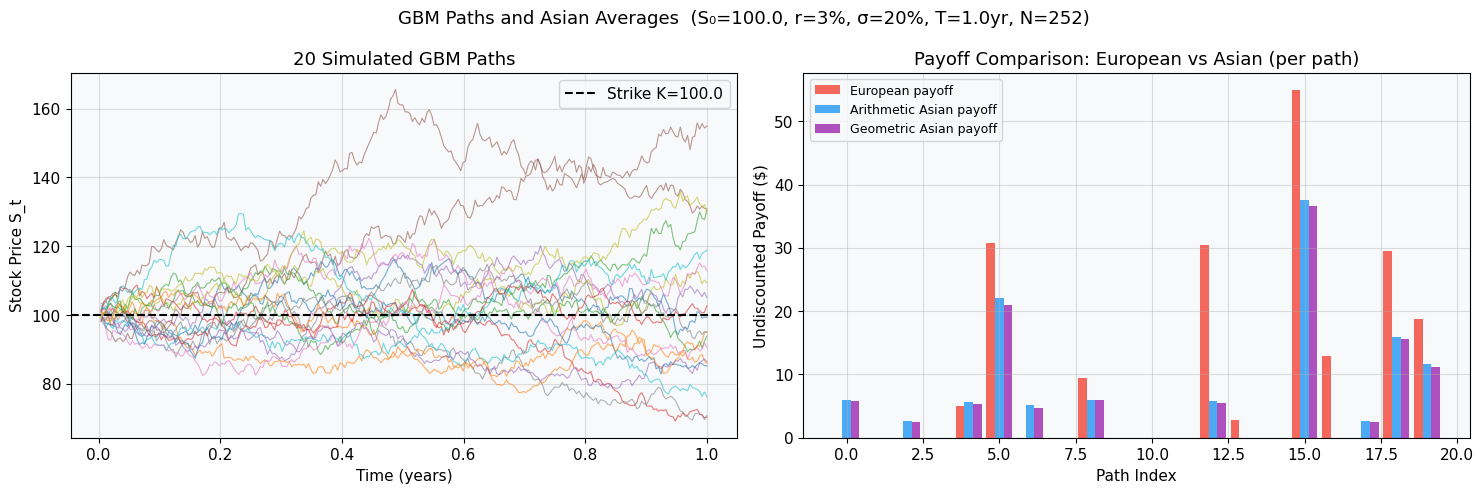


Path-level statistics (20 paths):
  Mean European payoff  : $9.7343
  Mean Arithmetic Asian : $6.0380
  Mean Geometric Asian  : $5.8272
  AM-GM holds for all paths: True


In [2]:
# Simulate a small number of paths for visualisation
n_vis = 20
paths_vis = simulate_gbm_paths(mp.S0, mp.r, mp.sigma, mp.T, mp.N,
                                n_vis, seed=0, antithetic=False)
t_grid = np.linspace(0, mp.T, mp.N + 1)[1:]   # monitoring dates (no t=0)

A_arith_vis = paths_vis.mean(axis=1)           # arithmetic average for each path
A_geo_vis   = np.exp(np.log(paths_vis).mean(axis=1))  # geometric average

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'GBM Paths and Asian Averages  (S₀={mp.S0}, r={mp.r:.0%}, σ={mp.sigma:.0%}, T={mp.T}yr, N={mp.N})',
             fontsize=13)

# Left: paths
for i in range(n_vis):
    axes[0].plot(t_grid, paths_vis[i], lw=0.8, alpha=0.6)
axes[0].axhline(mp.K, color='black', lw=1.5, ls='--', label=f'Strike K={mp.K}')
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Stock Price S_t')
axes[0].set_title(f'{n_vis} Simulated GBM Paths')
axes[0].legend()

# Right: payoff comparison per path
payoff_arith = np.maximum(A_arith_vis - mp.K, 0)
payoff_geo   = np.maximum(A_geo_vis   - mp.K, 0)
payoff_van   = np.maximum(paths_vis[:, -1] - mp.K, 0)   # terminal price = European

x_idx = np.arange(n_vis)
width = 0.28
axes[1].bar(x_idx - width, payoff_van,   width, label='European payoff',       color='#F44336', alpha=0.8)
axes[1].bar(x_idx,         payoff_arith, width, label='Arithmetic Asian payoff', color='#2196F3', alpha=0.8)
axes[1].bar(x_idx + width, payoff_geo,   width, label='Geometric Asian payoff',  color='#9C27B0', alpha=0.8)
axes[1].set_xlabel('Path Index')
axes[1].set_ylabel('Undiscounted Payoff ($)')
axes[1].set_title('Payoff Comparison: European vs Asian (per path)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nPath-level statistics (20 paths):")
print(f"  Mean European payoff  : ${payoff_van.mean():.4f}")
print(f"  Mean Arithmetic Asian : ${payoff_arith.mean():.4f}")
print(f"  Mean Geometric Asian  : ${payoff_geo.mean():.4f}")
print(f"  AM-GM holds for all paths: {(A_geo_vis <= A_arith_vis + 1e-10).all()}")

## 4. Variance Reduction: Antithetic Variates

For every draw $Z \sim \mathcal{N}(0,1)$ we also simulate $-Z$.

Since $V(Z)$ and $V(-Z)$ are **negatively correlated**:

$$\text{Var}\!\left[\tfrac{V(Z) + V(-Z)}{2}\right] = \tfrac{1}{2}\text{Var}[V(Z)]\left(1 + \rho\right) \le \tfrac{1}{2}\text{Var}[V(Z)]$$

where $\rho = \text{Corr}[V(Z), V(-Z)] < 0$.

## 5. Variance Reduction: Geometric Control Variate

Let $G_m = e^{-rT}\max(A_{\text{geo},m} - K, 0)$ (geometric payoff, path $m$)  
and $\hat{G}_{\text{exact}}$ = closed-form geometric Asian price.

**Control-variate estimator:**

$$\hat{C}_{\text{CV}} = \hat{C}_{\text{crude}} + \hat{\beta}\,(\hat{G}_{\text{exact}} - \hat{G}_{\text{MC}})$$

$$\hat{\beta} = \frac{\widehat{\text{Cov}}(A_{\text{arith}}, G)}{\widehat{\text{Var}}(G)}$$

This exploits the high correlation between arithmetic and geometric payoffs.
Any MC overestimate of the geometric payoff predicts an overestimate of the
arithmetic payoff, which we subtract out.

In [3]:
# Compare all three estimators
print("Running variance reduction comparison (50k paths)...")
t0 = time.time()
vrc = variance_reduction_comparison(
    mp.S0, mp.K, mp.r, mp.sigma, mp.T, N=mp.N, n_paths=50_000, seed=42
)
elapsed = time.time() - t0
print(f"Done in {elapsed:.2f}s\n")

geo_exact = geometric_asian_call(mp.S0, mp.K, mp.r, mp.sigma, mp.T, mp.N)
vanilla   = bs_call_price(mp.S0, mp.K, mp.r, mp.sigma, mp.T)

print(f"{'Method':<35}  {'Price':>10}  {'Std Error':>10}  {'VR Ratio':>10}")
print("-" * 73)
print(f"{'Crude MC (no variance reduction)':<35}  ${vrc['crude'].price_crude:>9.6f}  {vrc['se_crude']:>10.6f}  {'1.00x':>10}")
print(f"{'+ Antithetic variates':<35}  ${vrc['antithetic'].price_crude:>9.6f}  {vrc['se_antithetic']:>10.6f}  "
      f"{vrc['speedup_av_vs_crude']:>9.2f}x")
print(f"{'+ Antithetic + Geometric CV':<35}  ${vrc['cv'].price:>9.6f}  {vrc['se_cv']:>10.6f}  "
      f"{vrc['speedup_cv_vs_crude']:>9.2f}x")
print("-" * 73)
print(f"{'Reference: Geometric Asian (exact)':<35}  ${geo_exact:>9.6f}")
print(f"{'Reference: European Vanilla (BS)':<35}  ${vanilla:>9.6f}")
print(f"\nControl-variate β̂ = {vrc['cv'].beta_cv:.6f}")
print(f"\nInterpretation:")
print(f"  Variance reduction of {vrc['speedup_cv_vs_crude']:.1f}x means the CV estimator")
print(f"  is equivalent to running {vrc['speedup_cv_vs_crude']:.0f}x more crude MC paths.")

Running variance reduction comparison (50k paths)...
Done in 0.46s

Method                                    Price   Std Error    VR Ratio
-------------------------------------------------------------------------
Crude MC (no variance reduction)     $ 5.293007    0.034613       1.00x
+ Antithetic variates                $ 5.333531    0.034853       0.99x
+ Antithetic + Geometric CV          $ 5.300881    0.000961    1297.24x
-------------------------------------------------------------------------
Reference: Geometric Asian (exact)   $ 5.103063
Reference: European Vanilla (BS)     $ 9.413403

Control-variate β̂ = 1.035071

Interpretation:
  Variance reduction of 1297.2x means the CV estimator
  is equivalent to running 1297x more crude MC paths.


## 6. Convergence Analysis

We verify that $\text{SE} \propto M^{-1/2}$ by plotting SE vs $M$ on a log-log scale.
The slope should be $-0.5$.

In [4]:
path_grid = [500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000]

print("Running convergence study...")
conv_results = convergence_study(
    mp.S0, mp.K, mp.r, mp.sigma, mp.T, N=mp.N,
    path_grid=path_grid, seed=42
)
print("Done.\n")

n_paths_arr = np.array([r['n_paths']  for r in conv_results])
prices_arr  = np.array([r['price']    for r in conv_results])
se_arr      = np.array([r['std_err']  for r in conv_results])
ci_lo_arr   = np.array([r['ci_lower'] for r in conv_results])
ci_hi_arr   = np.array([r['ci_upper'] for r in conv_results])
vr_arr      = np.array([r['vr_ratio'] for r in conv_results])

# Log-log slope (should be ≈ -0.5)
log_n  = np.log(n_paths_arr)
log_se = np.log(se_arr)
slope, intercept = np.polyfit(log_n, log_se, 1)

final_res = conv_results[-1]
print(f"{'Paths':>8}  {'CV Price':>10}  {'Std Error':>10}  {'95% CI Width':>13}  {'VR Ratio':>10}")
print("-" * 60)
for r in conv_results:
    print(f"{r['n_paths']:>8,}  ${r['price']:>9.6f}  {r['std_err']:>10.6f}  "
          f"{r['ci_width']:>12.6f}  {r['vr_ratio']:>9.1f}x")
print(f"\nLog-log slope of SE vs M: {slope:.4f}  (theoretical: -0.5000)")

Running convergence study...
Done.

   Paths    CV Price   Std Error   95% CI Width    VR Ratio
------------------------------------------------------------
     500  $ 5.300083    0.009882      0.038735     1513.9x
   1,000  $ 5.291572    0.006247      0.024488     1638.6x
   2,000  $ 5.294723    0.004555      0.017857     1507.6x
   5,000  $ 5.296006    0.002877      0.011279     1456.0x
  10,000  $ 5.299291    0.002080      0.008153     1352.8x
  20,000  $ 5.300235    0.001536      0.006022     1272.6x
  50,000  $ 5.300881    0.000961      0.003767     1315.2x
 100,000  $ 5.300660    0.000672      0.002634     1330.3x

Log-log slope of SE vs M: -0.4942  (theoretical: -0.5000)


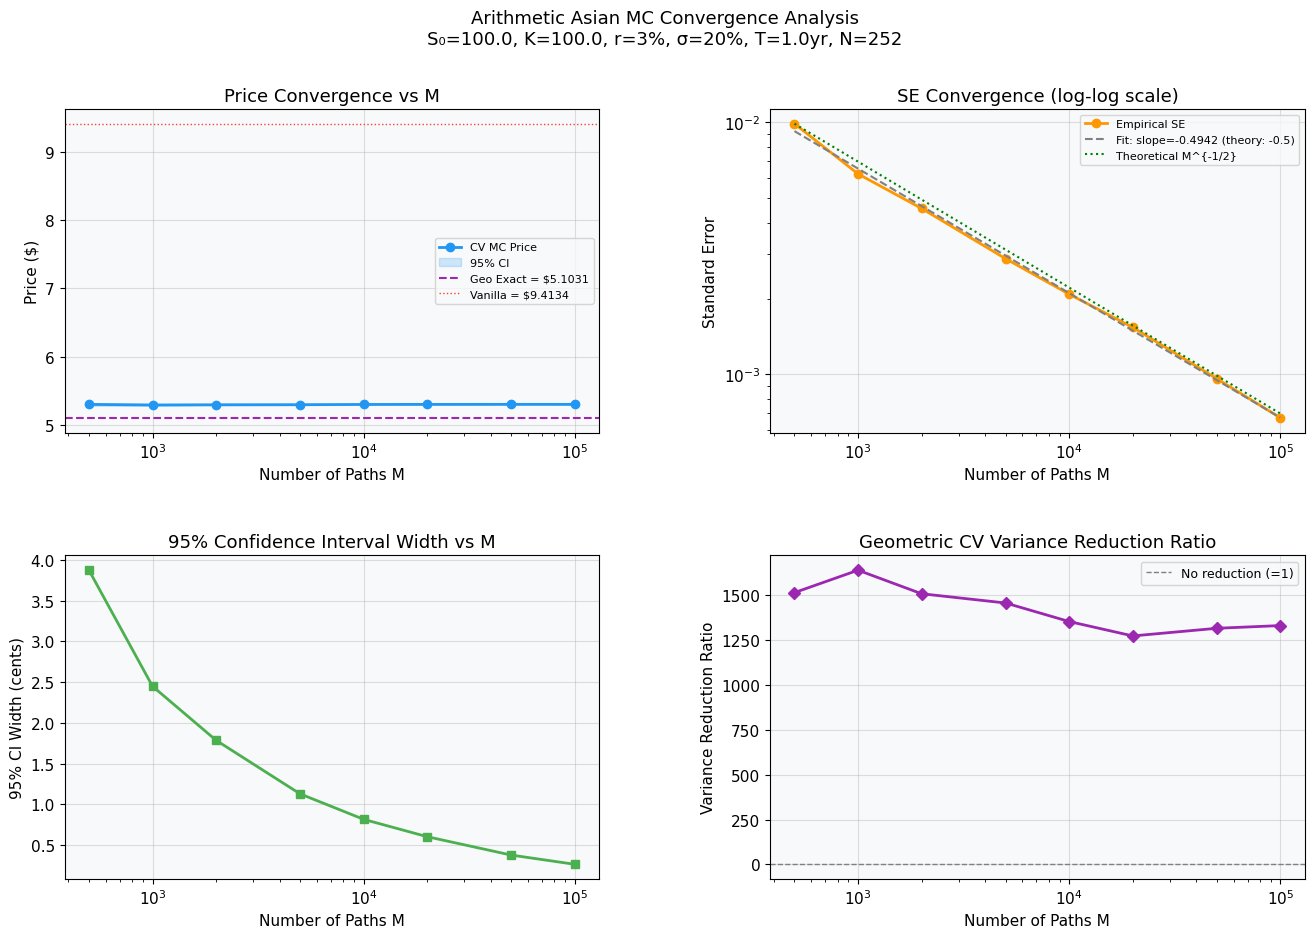

In [5]:
geo_exact = geometric_asian_call(mp.S0, mp.K, mp.r, mp.sigma, mp.T, mp.N)
vanilla   = bs_call_price(mp.S0, mp.K, mp.r, mp.sigma, mp.T)

fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.32)

# (0,0) Price convergence with CI ribbon
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogx(n_paths_arr, prices_arr, 'o-', color='#2196F3', lw=2, ms=6, label='CV MC Price')
ax1.fill_between(n_paths_arr, ci_lo_arr, ci_hi_arr, alpha=0.2, color='#2196F3', label='95% CI')
ax1.axhline(geo_exact, color='#9C27B0', lw=1.5, ls='--', label=f'Geo Exact = ${geo_exact:.4f}')
ax1.axhline(vanilla,   color='#F44336', lw=1,   ls=':',  label=f'Vanilla = ${vanilla:.4f}')
ax1.set_xlabel('Number of Paths M')
ax1.set_ylabel('Price ($)')
ax1.set_title('Price Convergence vs M')
ax1.legend(fontsize=8)

# (0,1) SE convergence (log-log)
ax2 = fig.add_subplot(gs[0, 1])
ax2.loglog(n_paths_arr, se_arr, 'o-', color='#FF9800', lw=2, ms=6, label='Empirical SE')
fit_line = np.exp(intercept) * n_paths_arr ** slope
ax2.loglog(n_paths_arr, fit_line, '--', color='grey', lw=1.5,
           label=f'Fit: slope={slope:.4f} (theory: -0.5)')
theoretical = se_arr[0] * np.sqrt(n_paths_arr[0] / n_paths_arr)
ax2.loglog(n_paths_arr, theoretical, ':', color='green', lw=1.5, label='Theoretical M^{-1/2}')
ax2.set_xlabel('Number of Paths M')
ax2.set_ylabel('Standard Error')
ax2.set_title('SE Convergence (log-log scale)')
ax2.legend(fontsize=8)

# (1,0) CI width
ax3 = fig.add_subplot(gs[1, 0])
ci_widths = ci_hi_arr - ci_lo_arr
ax3.semilogx(n_paths_arr, ci_widths * 100, 's-', color='#4CAF50', lw=2, ms=6)
ax3.set_xlabel('Number of Paths M')
ax3.set_ylabel('95% CI Width (cents)')
ax3.set_title('95% Confidence Interval Width vs M')

# (1,1) Variance reduction ratio
ax4 = fig.add_subplot(gs[1, 1])
ax4.semilogx(n_paths_arr, vr_arr, 'D-', color='#9C27B0', lw=2, ms=6)
ax4.axhline(1, color='grey', lw=1, ls='--', label='No reduction (=1)')
ax4.set_xlabel('Number of Paths M')
ax4.set_ylabel('Variance Reduction Ratio')
ax4.set_title('Geometric CV Variance Reduction Ratio')
ax4.legend(fontsize=9)

fig.suptitle('Arithmetic Asian MC Convergence Analysis\n'
             f'S₀={mp.S0}, K={mp.K}, r={mp.r:.0%}, σ={mp.sigma:.0%}, T={mp.T}yr, N={mp.N}',
             fontsize=13)
plt.show()

## 7. Antithetic Symmetry Demonstration

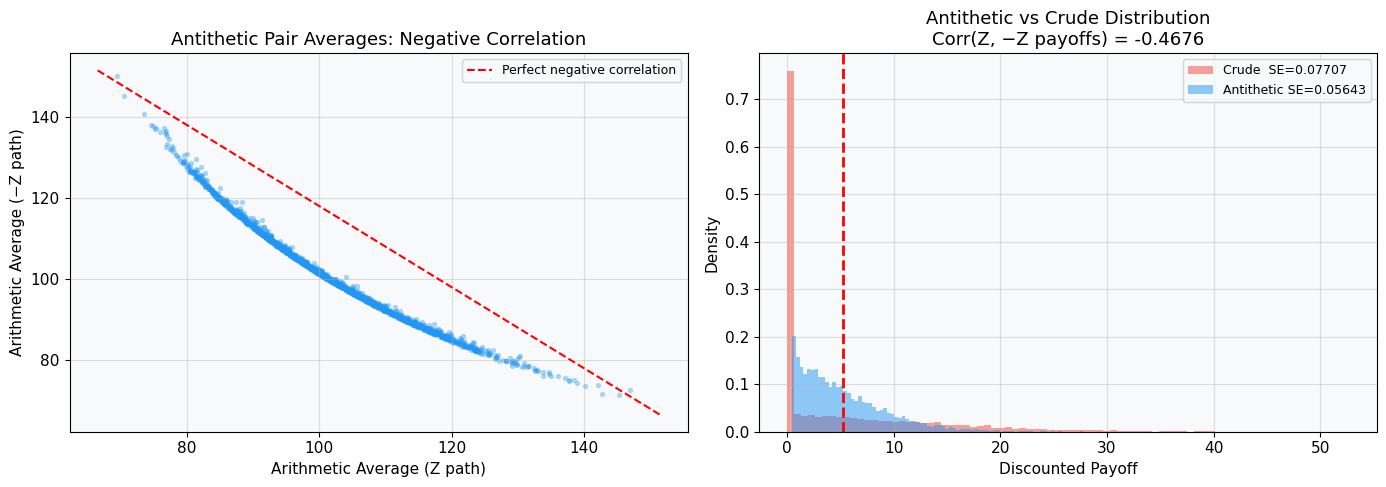

Correlation between antithetic pair payoffs: -0.4676
Variance reduction from antithetic: 0.2662 × crude var
  (Expected speedup: 1.88x since both halves combined)


In [6]:
# Show correlation between antithetic pair payoffs
n_demo = 10_000
paths_anti = simulate_gbm_paths(mp.S0, mp.r, mp.sigma, mp.T, mp.N,
                                  n_demo, seed=5, antithetic=True)
disc = np.exp(-mp.r * mp.T)
half = n_demo // 2

A_first  = paths_anti[:half, :].mean(axis=1)
A_second = paths_anti[half:,  :].mean(axis=1)
pay_first  = disc * np.maximum(A_first  - mp.K, 0)
pay_second = disc * np.maximum(A_second - mp.K, 0)

corr_anti = np.corrcoef(pay_first, pay_second)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter of antithetic pair averages
idx = np.random.choice(half, 2000, replace=False)
axes[0].scatter(A_first[idx], A_second[idx], alpha=0.3, s=8, color='#2196F3')
axes[0].plot([A_first.min(), A_first.max()],
             [A_first.max(), A_first.min()],
             'r--', lw=1.5, label='Perfect negative correlation')
axes[0].set_xlabel('Arithmetic Average (Z path)')
axes[0].set_ylabel('Arithmetic Average (−Z path)')
axes[0].set_title('Antithetic Pair Averages: Negative Correlation')
axes[0].legend(fontsize=9)

# Distribution: crude vs antithetic
pay_crude = disc * np.maximum(
    simulate_gbm_paths(mp.S0, mp.r, mp.sigma, mp.T, mp.N,
                       n_demo, seed=5, antithetic=False).mean(axis=1) - mp.K, 0
)
pay_anti_avg = (pay_first + pay_second) / 2

axes[1].hist(pay_crude,    bins=80, alpha=0.5, density=True, color='#F44336', label=f'Crude  SE={pay_crude.std()/np.sqrt(n_demo):.5f}')
axes[1].hist(pay_anti_avg, bins=80, alpha=0.5, density=True, color='#2196F3', label=f'Antithetic SE={pay_anti_avg.std()/np.sqrt(half):.5f}')
axes[1].axvline(pay_crude.mean(), color='red', lw=2, ls='--')
axes[1].set_xlabel('Discounted Payoff')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Antithetic vs Crude Distribution\nCorr(Z, −Z payoffs) = {corr_anti:.4f}')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Correlation between antithetic pair payoffs: {corr_anti:.4f}")
print(f"Variance reduction from antithetic: {(1 + corr_anti)/2:.4f} × crude var")
print(f"  (Expected speedup: {1 / ((1 + corr_anti)):.2f}x since both halves combined)")

## 8. Final Price Table: Three Methods Compared

In [7]:
res_full = arithmetic_asian_mc(
    mp.S0, mp.K, mp.r, mp.sigma, mp.T, N=mp.N,
    n_paths=200_000, seed=42, use_cv=True, use_antithetic=True
)

geo_exact = geometric_asian_call(mp.S0, mp.K, mp.r, mp.sigma, mp.T, mp.N)
vanilla   = bs_call_price(mp.S0, mp.K, mp.r, mp.sigma, mp.T)

print("=" * 65)
print("  Arithmetic Asian Call — Final Pricing Summary")
print(f"  Baseline: S₀={mp.S0}, K={mp.K}, r={mp.r:.0%}, σ={mp.sigma:.0%}, T={mp.T}yr, N={mp.N}")
print("=" * 65)
print(f"  Arithmetic Asian (MC 200k, antithetic+CV):")
print(f"    Price  : ${res_full.price:.6f}")
print(f"    Std Err: {res_full.std_err:.6f}")
print(f"    95% CI : [${res_full.ci_lower:.6f},  ${res_full.ci_upper:.6f}]")
print(f"    Beta CV: {res_full.beta_cv:.6f}")
print(f"    VR     : {res_full.variance_reduction_ratio:.1f}x")
print(f"  ───────────────────────────────────────────")
print(f"  Geometric Asian (closed-form exact)  : ${geo_exact:.6f}")
print(f"  European Vanilla (Black-Scholes)     : ${vanilla:.6f}")
print("=" * 65)
print(f"  Price ordering: Geo ({geo_exact:.4f}) < Arith ({res_full.price:.4f}) < Vanilla ({vanilla:.4f})")
print(f"  This confirms AM-GM inequality holds in expectation.")
print(res_full)

  Arithmetic Asian Call — Final Pricing Summary
  Baseline: S₀=100.0, K=100.0, r=3%, σ=20%, T=1.0yr, N=252
  Arithmetic Asian (MC 200k, antithetic+CV):
    Price  : $5.300215
    Std Err: 0.000473
    95% CI : [$5.299288,  $5.301141]
    Beta CV: 1.034722
    VR     : 1350.8x
  ───────────────────────────────────────────
  Geometric Asian (closed-form exact)  : $5.103063
  European Vanilla (Black-Scholes)     : $9.413403
  Price ordering: Geo (5.1031) < Arith (5.3002) < Vanilla (9.4134)
  This confirms AM-GM inequality holds in expectation.
ArithmeticMCResult(
  price            = 5.300215
  price_crude      = 5.310641
  std_err          = 0.000473
  95% CI           = [5.299288, 5.301141]
  beta_cv          = 1.034722
  n_paths          = 200000
  VR ratio         = 1350.76x
)
